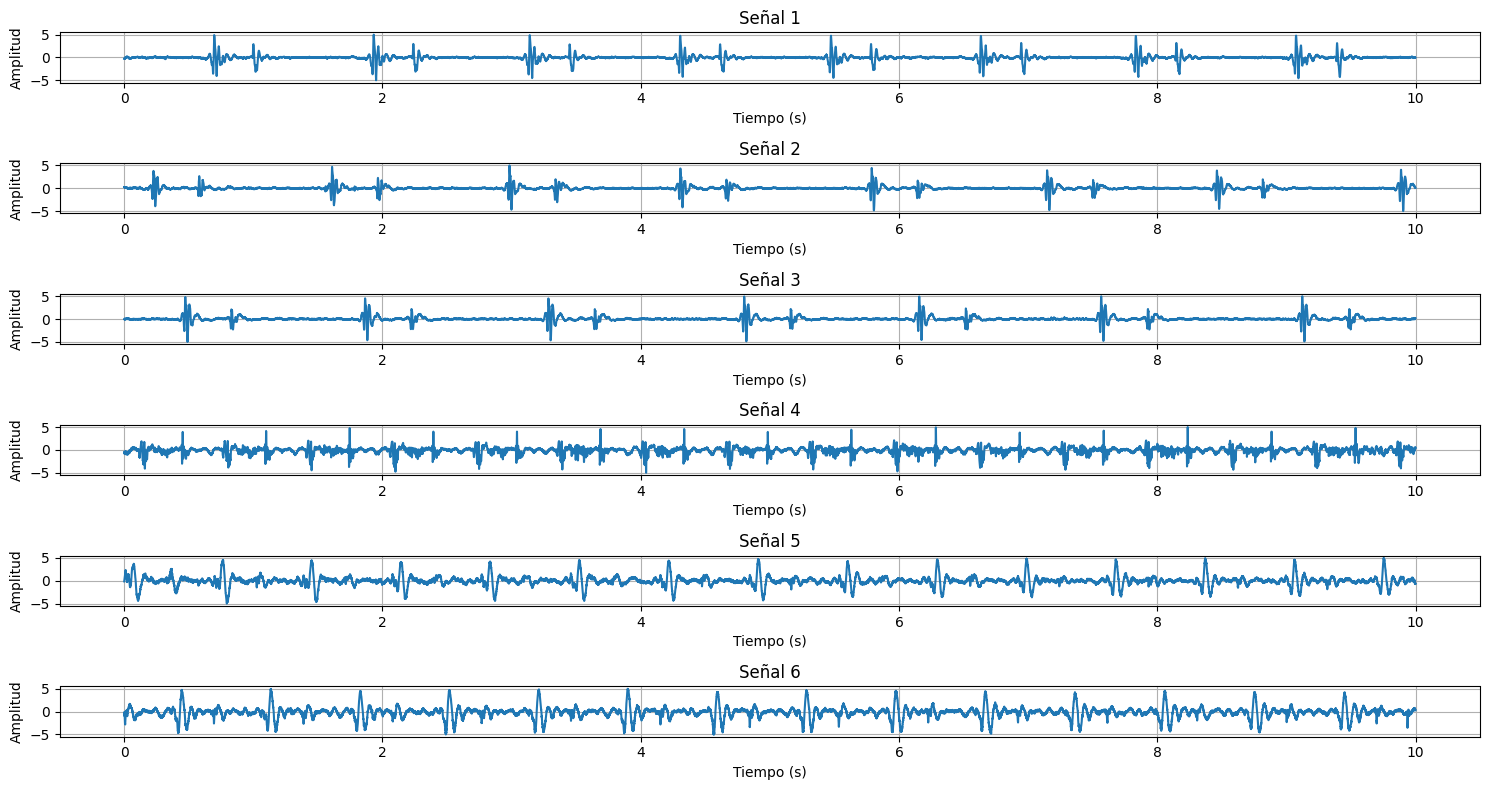

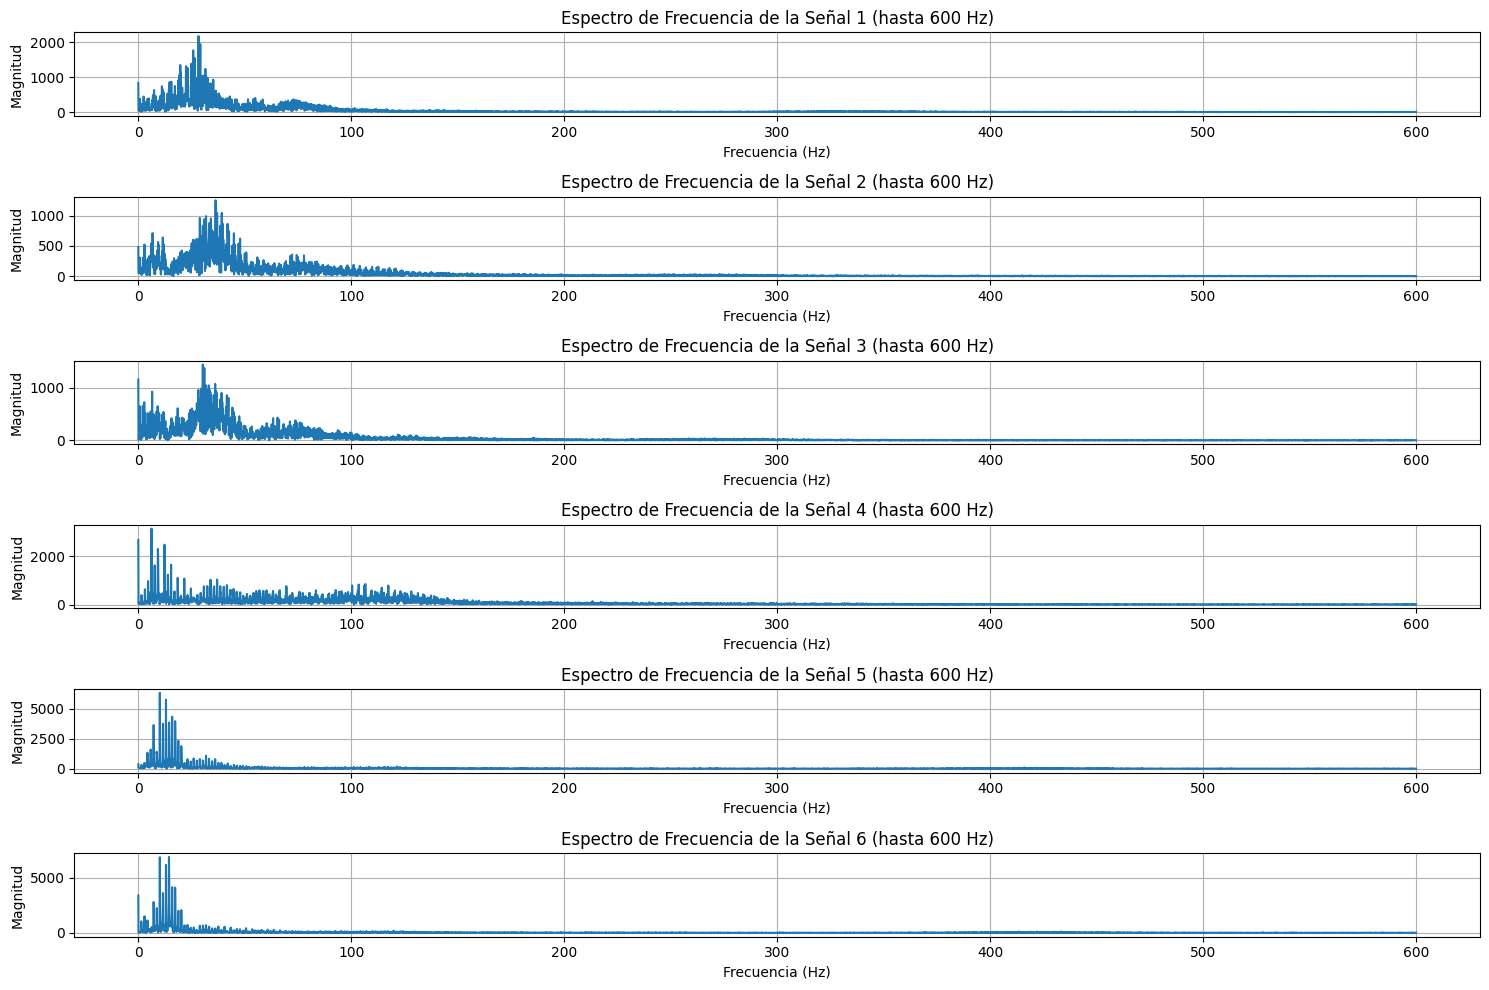

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, welch
from scipy.spatial.distance import euclidean
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
 
plt.close("all")
 
# Cargar los datos desde el archivo
file_path = r"D:\Upiita\6to\Patrones\Objetos\Signals10seg.txt"

data = np.loadtxt(file_path)
 
# Parámetros
fs = 2000  # Frecuencia de muestreo
t = np.arange(data.shape[0]) / fs  # Vector de tiempo basado en la frecuencia de muestreo
 
# Visualizar las señales
plt.figure(figsize=(15, 8))
for i in range(data.shape[1]):
    plt.subplot(6, 1, i + 1)
    plt.plot(t, data[:, i])
    plt.title(f'Señal {i + 1}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid()
 
plt.tight_layout()
plt.show()
 
# Análisis en el dominio de la frecuencia
plt.figure(figsize=(15, 10))
frequencies = np.fft.rfftfreq(data.shape[0], d=1/fs)  # Frecuencias correspondientes
max_frequency = 600  # Frecuencia máxima a mostrar
for i in range(data.shape[1]):
    fft_magnitude = np.abs(np.fft.rfft(data[:, i]))  # Magnitud de la FFT
 
    # Filtrar hasta 600 Hz
    freq_mask = frequencies <= max_frequency
    filtered_frequencies = frequencies[freq_mask]
    filtered_magnitude = fft_magnitude[freq_mask]
 
    # Graficar
    plt.subplot(6, 1, i + 1)
    plt.plot(filtered_frequencies, filtered_magnitude)
    plt.title(f'Espectro de Frecuencia de la Señal {i + 1} (hasta 600 Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.grid()
 
plt.tight_layout()
plt.show()

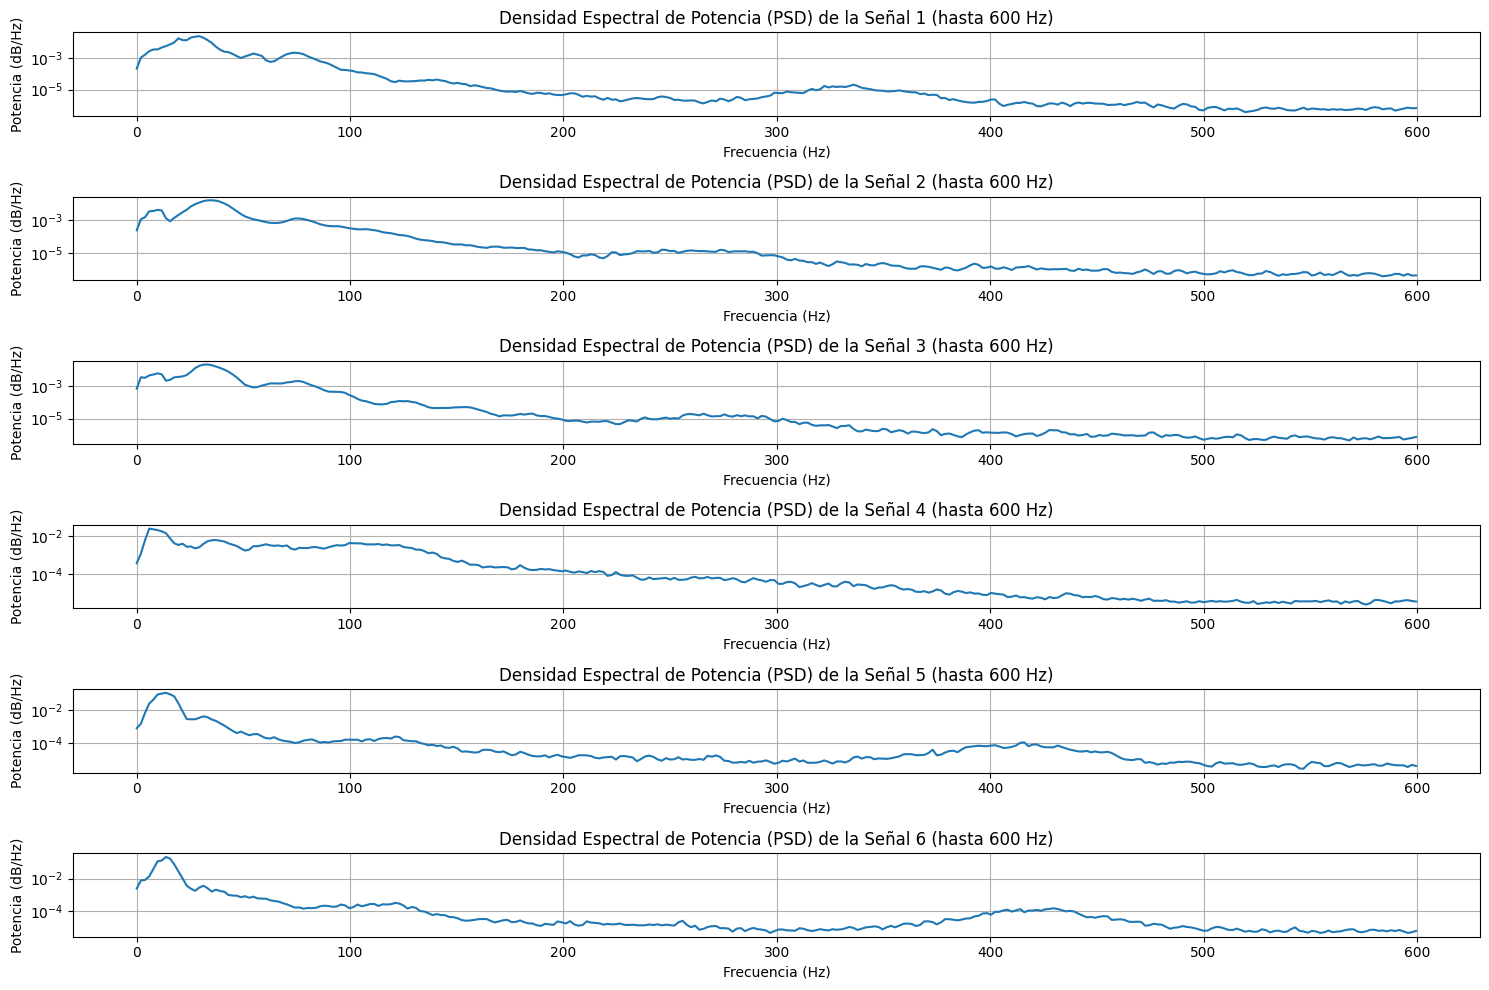

Distancia Euclidiana en el dominio de la frecuencia:
Matriz de distancias (frecuencia):
[[    0.          7720.73692809  8032.28450315 11616.18835367
  15730.15048957 17778.74250943]
 [ 7720.73692809     0.          5362.94723832 10253.68175954
  15350.05441143 17858.14323706]
 [ 8032.28450315  5362.94723832     0.         10455.60206741
  15630.6732364  17916.28575884]
 [11616.18835367 10253.68175954 10455.60206741     0.
  17430.59050074 18982.84167694]
 [15730.15048957 15350.05441143 15630.6732364  17430.59050074
      0.          7556.3166663 ]
 [17778.74250943 17858.14323706 17916.28575884 18982.84167694
   7556.3166663      0.        ]]

Correlación cruzada en el dominio del tiempo:
Matriz de correlaciones:
[[    0.          2149.92036935  2232.8660327   1440.79562628
   1109.75374265  1306.71800531]
 [ 2149.92036935     0.          5264.14197161  1159.77808303
   1092.68245717   829.9922845 ]
 [ 2232.8660327   5264.14197161     0.          1014.90890808
   1090.52106049   631.29

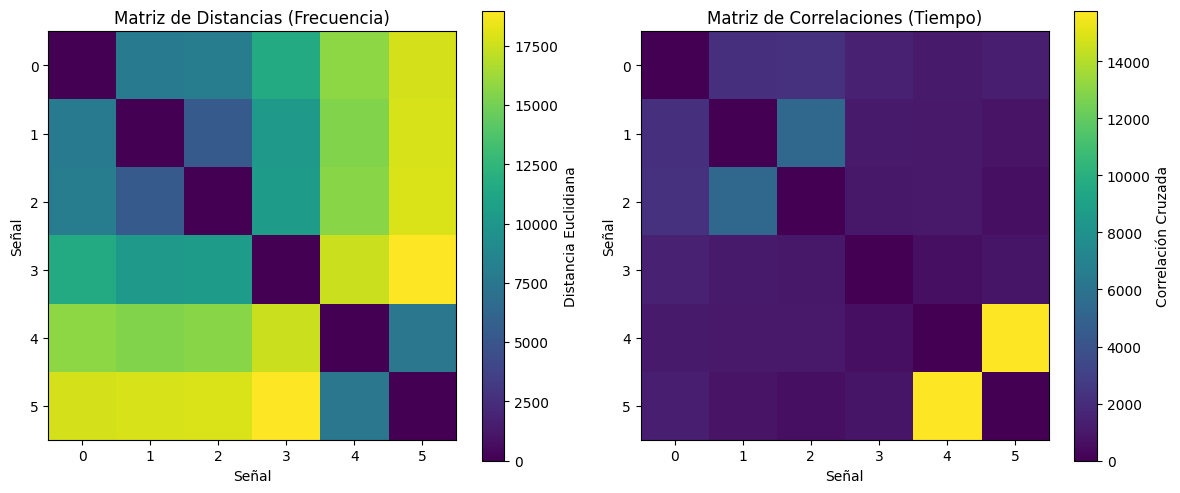

In [2]:
# Análisis de Densidad Espectral de Potencia (PSD)
plt.figure(figsize=(15, 10))
for i in range(data.shape[1]):
    # Calcular la PSD usando el método de Welch
    psd_frequencies, psd = welch(data[:, i], fs=fs, nperseg=1024)
 
    # Filtrar hasta 600 Hz
    psd_mask = psd_frequencies <= max_frequency
    filtered_psd_frequencies = psd_frequencies[psd_mask]
    filtered_psd = psd[psd_mask]
 
    # Graficar la PSD
    plt.subplot(6, 1, i + 1)
    plt.semilogy(filtered_psd_frequencies, filtered_psd)  # Escala logarítmica para PSD
    plt.title(f'Densidad Espectral de Potencia (PSD) de la Señal {i + 1} (hasta 600 Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Potencia (dB/Hz)')
    plt.grid()
 
plt.tight_layout()
plt.show()
 
# --------------------
# 1. Distancia Euclidiana en el dominio de la frecuencia
# --------------------
print("Distancia Euclidiana en el dominio de la frecuencia:")
frequencies = np.fft.rfftfreq(data.shape[0], d=1/fs)  # Frecuencias correspondientes
distances = np.zeros((data.shape[1], data.shape[1]))
 
for i in range(data.shape[1]):
    for j in range(data.shape[1]):
        if i != j:
            # Calcula FFT
            fft_i = np.abs(np.fft.rfft(data[:, i]))
            fft_j = np.abs(np.fft.rfft(data[:, j]))
 
            # Filtra hasta 600 Hz
            freq_mask = frequencies <= max_frequency
            fft_i_filtered = fft_i[freq_mask]
            fft_j_filtered = fft_j[freq_mask]
 
            # Calcula la distancia Euclidiana
            distances[i, j] = euclidean(fft_i_filtered, fft_j_filtered)
 
# Mostrar matriz de distancias
print("Matriz de distancias (frecuencia):")
print(distances)
 
# --------------------
# 2. Correlación cruzada en el dominio del tiempo
# --------------------
print("\nCorrelación cruzada en el dominio del tiempo:")
correlations = np.zeros((data.shape[1], data.shape[1]))
 
for i in range(data.shape[1]):
    for j in range(data.shape[1]):
        if i != j:
            # Calcula la correlación cruzada normalizada
            corr = correlate(data[:, i], data[:, j], mode='full')
            correlations[i, j] = np.max(corr) / (np.std(data[:, i]) * np.std(data[:, j]))
 
# Mostrar matriz de correlaciones
print("Matriz de correlaciones:")
print(correlations)
 
# --------------------
# Visualizar las matrices
# --------------------
plt.figure(figsize=(12, 5))
 
# Distancia Euclidiana
plt.subplot(1, 2, 1)
plt.imshow(distances, cmap='viridis', interpolation='none')
plt.colorbar(label='Distancia Euclidiana')
plt.title('Matriz de Distancias (Frecuencia)')
plt.xlabel('Señal')
plt.ylabel('Señal')
 
# Correlación cruzada
plt.subplot(1, 2, 2)
plt.imshow(correlations, cmap='viridis', interpolation='none')
plt.colorbar(label='Correlación Cruzada')
plt.title('Matriz de Correlaciones (Tiempo)')
plt.xlabel('Señal')
plt.ylabel('Señal')
 
plt.tight_layout()
plt.show()

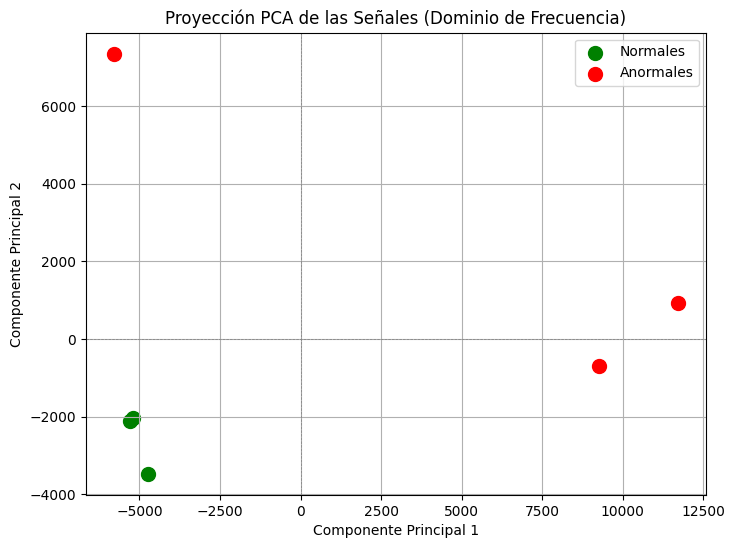

In [ ]:
# Preparar los datos en el dominio de la frecuencia (FFT) para PCA compresión de datos
fft_data = []
for i in range(data.shape[1]):
    fft_magnitude = np.abs(np.fft.rfft(data[:, i]))  # Magnitud de la FFT
    freq_mask = frequencies <= max_frequency        # Filtrar hasta 600 Hz
    fft_data.append(fft_magnitude[freq_mask])
 
fft_data = np.array(fft_data)  # Convertir a matriz
 
# Aplicar PCA al dominio de frecuencia
pca = PCA(n_components=2)  # Reducimos a 2 componentes principales
fft_pca_result = pca.fit_transform(fft_data)
 
# Visualizar los resultados de PCA
plt.figure(figsize=(8, 6))
plt.scatter(fft_pca_result[:3, 0], fft_pca_result[:3, 1], color='green', label='Normales', s=100)
plt.scatter(fft_pca_result[3:, 0], fft_pca_result[3:, 1], color='red', label='Anormales', s=100)
plt.title('Proyección PCA de las Señales (Dominio de Frecuencia)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.grid()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def optimized_dtw_distance(signal1, signal2):
    """
    Calcula la distancia DTW entre dos señales de forma optimizada usando solo dos filas de la matriz.
    :param signal1: Primera señal (array)
    :param signal2: Segunda señal (array)
    :return: Distancia DTW
    """
    n, m = len(signal1), len(signal2)
    prev_row = np.full(m + 1, np.inf)
    curr_row = np.full(m + 1, np.inf)
    prev_row[0] = 0
 
    for i in range(1, n + 1):
        curr_row[0] = np.inf
        for j in range(1, m + 1):
            cost = abs(signal1[i - 1] - signal2[j - 1])
            curr_row[j] = cost + min(prev_row[j], curr_row[j - 1], prev_row[j - 1])
        prev_row, curr_row = curr_row, prev_row
 
    return prev_row[m]



In [2]:
file_path = r"D:\Upiita\6to\Patrones\Objetos\Signals10seg.txt"
data = np.loadtxt(file_path)

In [3]:
fs = 2000  # Frecuencia de muestreo
duration = 2  # Duración en segundos
samples = fs * duration  # Número de muestras para 2 segundos
short_data = data[:samples, :]  # Tomar las primeras 2 segundos de cada señal
 
# Reducir la resolución temporal (muestreo reducido)
downsample_factor = 4  # Reducir la frecuencia de muestreo a 1/4 (500 Hz)
downsampled_data = short_data[::downsample_factor, :]  # Reducir las muestras

num_signals = downsampled_data.shape[1]
dtw_distances = np.zeros((num_signals, num_signals))
 
for i in range(num_signals):
    for j in range(num_signals):
        if i != j:
            # Calcular DTW entre la señal i y la señal j
            distance = optimized_dtw_distance(downsampled_data[:, i], downsampled_data[:, j])
            dtw_distances[i, j] = distance

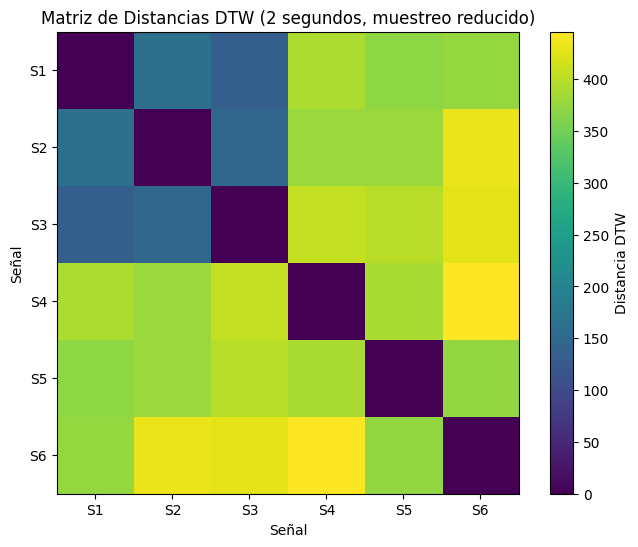

In [4]:
plt.figure(figsize=(8, 6))
plt.imshow(dtw_distances, cmap='viridis', interpolation='none')
plt.colorbar(label='Distancia DTW')
plt.title('Matriz de Distancias DTW (2 segundos, muestreo reducido)')
plt.xlabel('Señal')
plt.ylabel('Señal')
plt.xticks(ticks=range(num_signals), labels=[f"S{i+1}" for i in range(num_signals)])
plt.yticks(ticks=range(num_signals), labels=[f"S{i+1}" for i in range(num_signals)])
plt.show()